In [2]:
"""
# 🏦 CreditSense: Loan Risk Assessment — Baseline Template

## Your Two Tasks

**Task A — Classification:** Predict `RiskTier` (0 to 4)
- 0 = Very Low Risk → 4 = Very High Risk

**Task B — Regression:** Predict `InterestRate` (%)
- Annual percentage rate offered to the applicant
- Range: 4.99% (best) to 35.99% (worst)

## What this baseline does
- Loads and preprocesses the data
- Trains a **Logistic Regression** for Task A (~53% accuracy)
- Trains a **Linear Regression** for Task B (R² ~0.50)
- Saves a submission file

**Your goal: beat both baselines!**
"""

'\n# 🏦 CreditSense: Loan Risk Assessment — Baseline Template\n\n## Your Two Tasks\n\n**Task A — Classification:** Predict `RiskTier` (0 to 4)\n- 0 = Very Low Risk → 4 = Very High Risk\n\n**Task B — Regression:** Predict `InterestRate` (%)\n- Annual percentage rate offered to the applicant\n- Range: 4.99% (best) to 35.99% (worst)\n\n## What this baseline does\n- Loads and preprocesses the data\n- Trains a **Logistic Regression** for Task A (~53% accuracy)\n- Trains a **Linear Regression** for Task B (R² ~0.50)\n- Saves a submission file\n\n**Your goal: beat both baselines!**\n'

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             r2_score, mean_squared_error)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")


Libraries loaded!


In [4]:
train = pd.read_csv('creditsense-ai1215/credit_train.csv')

X     = train.drop(['RiskTier', 'InterestRate'], axis=1)
y_cls = train['RiskTier']
y_reg = train['InterestRate']

print(f"Dataset shape: {X.shape}")
print(f"\nTask A — RiskTier distribution:\n{y_cls.value_counts().sort_index()}")
print(f"\nTask B — InterestRate summary:\n{y_reg.describe().round(2)}")

# TODO: Explore the data further
# X.isnull().sum()       ← check missing values
# X.describe()           ← check feature ranges
# X.dtypes               ← check feature types

Dataset shape: (35000, 55)

Task A — RiskTier distribution:
RiskTier
0    6724
1    7283
2    6998
3    6812
4    7183
Name: count, dtype: int64

Task B — InterestRate summary:
count    35000.00
mean         7.31
std          4.19
min          4.99
25%          4.99
50%          6.08
75%          7.94
max         35.99
Name: InterestRate, dtype: float64


In [5]:
def simple_preprocess(X_train, X_test=None):
    """
    Fill missing values, add missing-value indicators, and encode categorical features.
    """
    X_train = X_train.copy()
    if X_test is not None:
        X_test = X_test.copy()

    base_cols = X_train.columns.tolist()
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    # Add missing indicators BEFORE imputation so the model can learn missingness effects.
    missing_indicator_cols = []
    for col in base_cols:
        train_missing = X_train[col].isna()
        test_missing = X_test[col].isna() if X_test is not None else None

        if train_missing.any() or (test_missing is not None and test_missing.any()):
            ind_col = f"{col}_is_missing"
            X_train[ind_col] = train_missing.astype(np.int8)
            if X_test is not None:
                X_test[ind_col] = test_missing.astype(np.int8)
            missing_indicator_cols.append(ind_col)

    print(
        f"Numeric: {len(num_cols)} | Categorical: {len(cat_cols)} | "
        f"Missing indicators: {len(missing_indicator_cols)}"
    )

    # Numeric -> fill with train median
    for col in num_cols:
        med = X_train[col].median()
        X_train[col] = X_train[col].fillna(med)
        if X_test is not None:
            X_test[col] = X_test[col].fillna(med)

    # Categorical -> fill with train mode, then label encode
    for col in cat_cols:
        mode_series = X_train[col].mode(dropna=True)
        mode = mode_series.iloc[0] if not mode_series.empty else 'Unknown'

        X_train[col] = X_train[col].fillna(mode)
        if X_test is not None:
            X_test[col] = X_test[col].fillna(mode)

        le = LabelEncoder()
        if X_test is not None:
            combined = pd.concat([X_train[col].astype(str), X_test[col].astype(str)], axis=0)
            le.fit(combined)
            X_train[col] = le.transform(X_train[col].astype(str))
            X_test[col] = le.transform(X_test[col].astype(str))
        else:
            X_train[col] = le.fit_transform(X_train[col].astype(str))

    X_train = X_train.fillna(0)
    if X_test is not None:
        X_test = X_test.fillna(0)
        return X_train, X_test

    return X_train


X_processed = simple_preprocess(X)
print(f"\nAfter preprocessing — shape: {X_processed.shape} | missing: {X_processed.isnull().sum().sum()}")


Numeric: 46 | Categorical: 9 | Missing indicators: 16

After preprocessing — shape: (35000, 71) | missing: 0


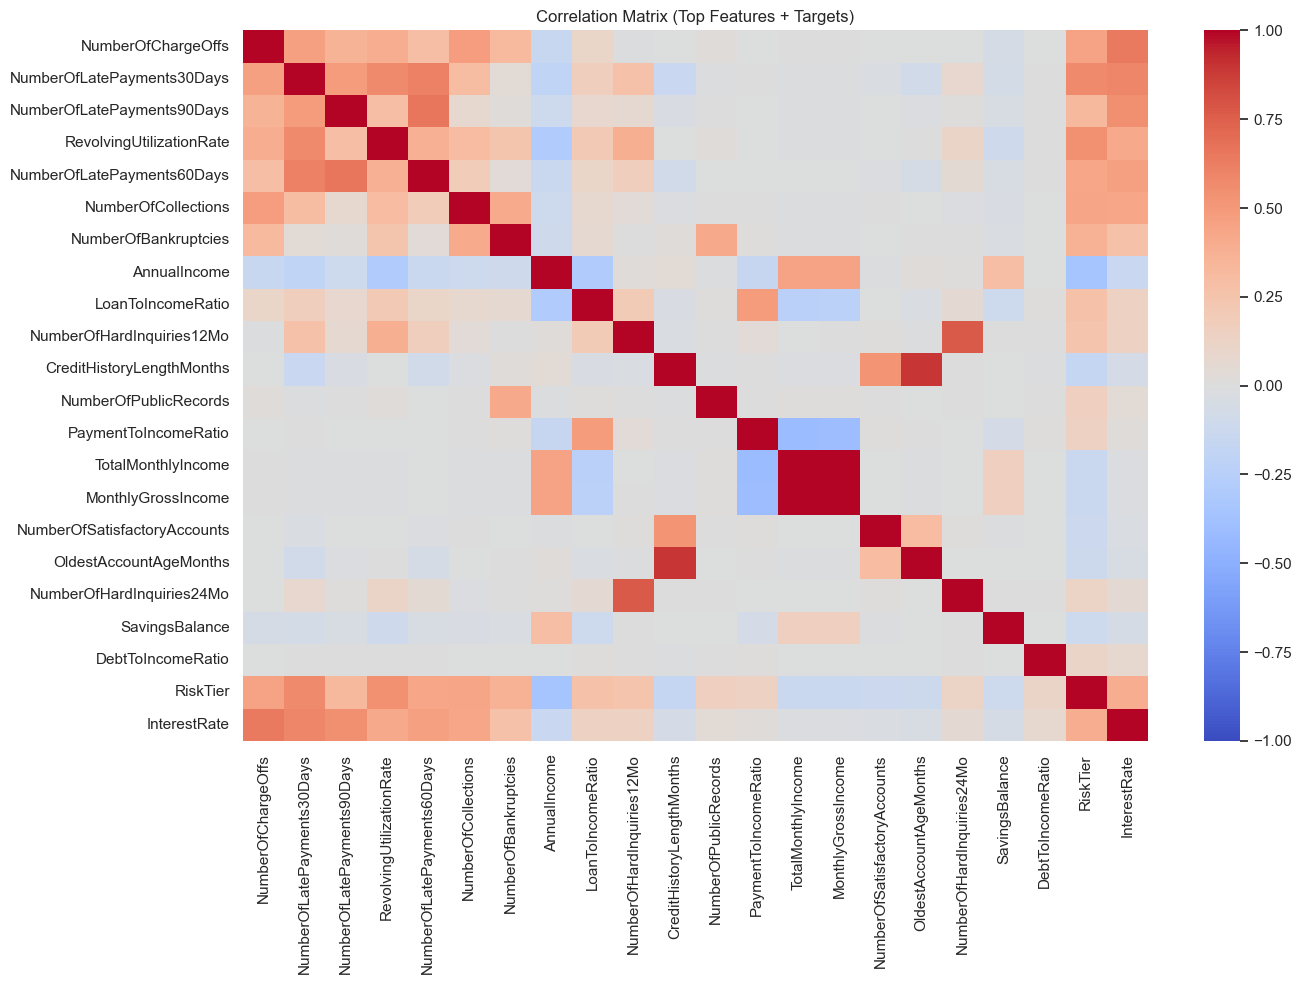

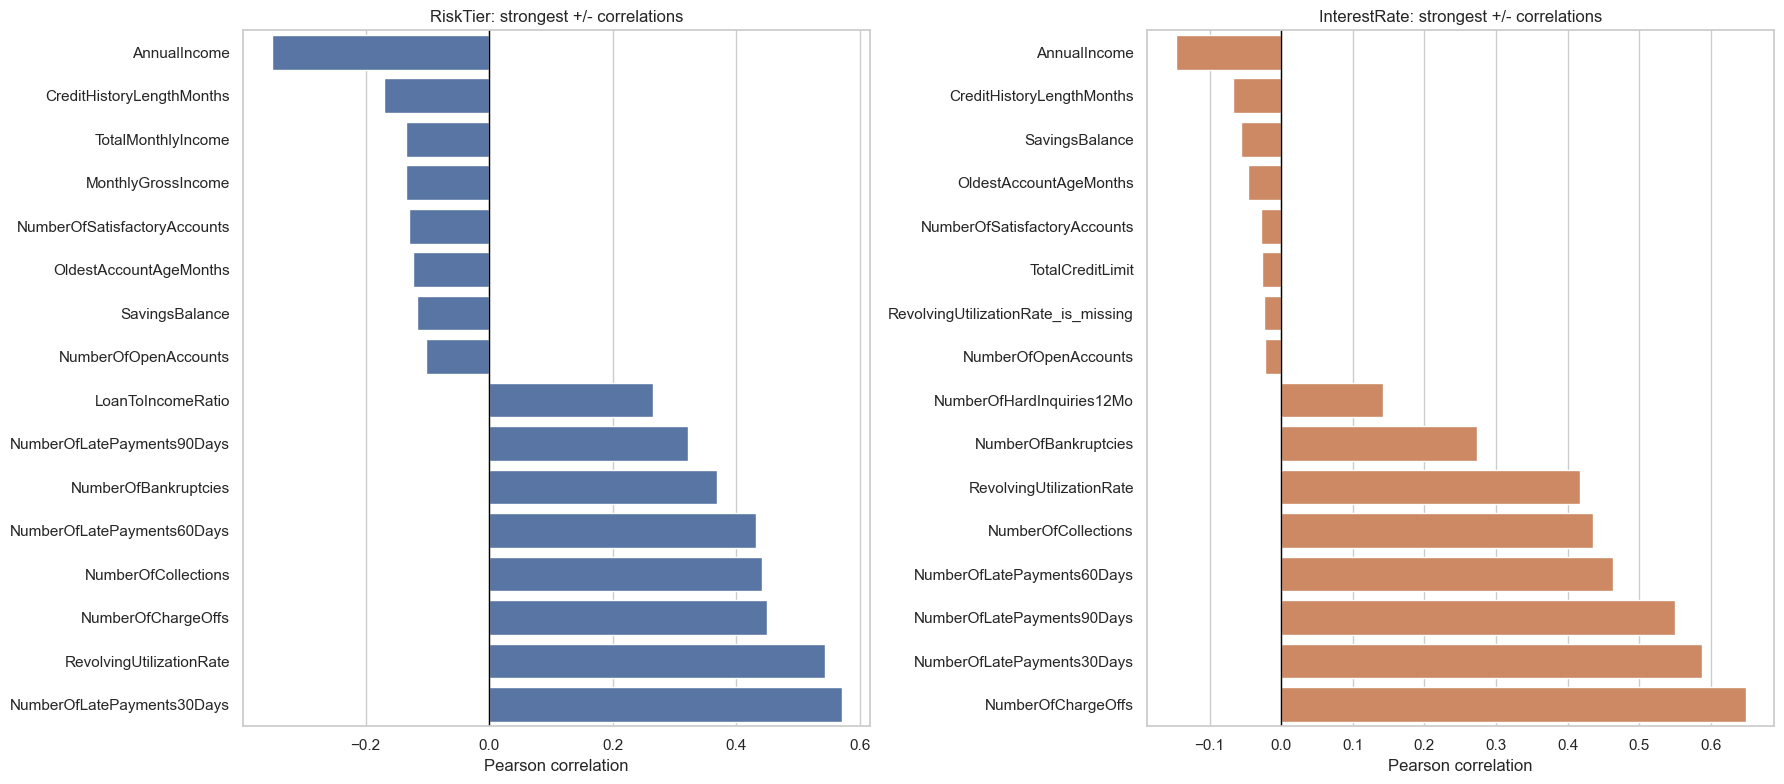

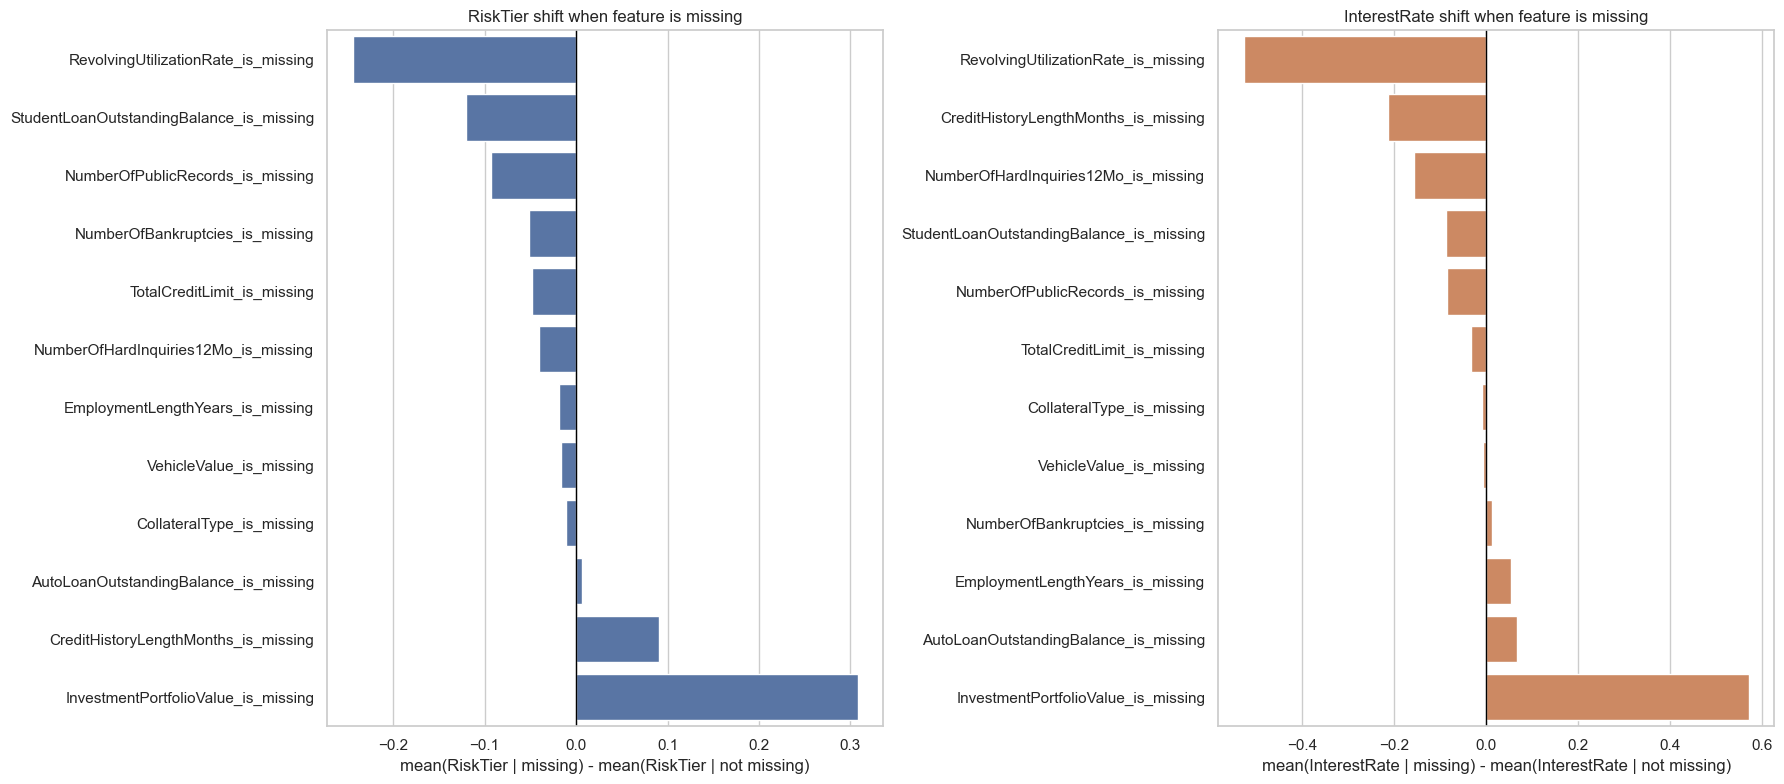

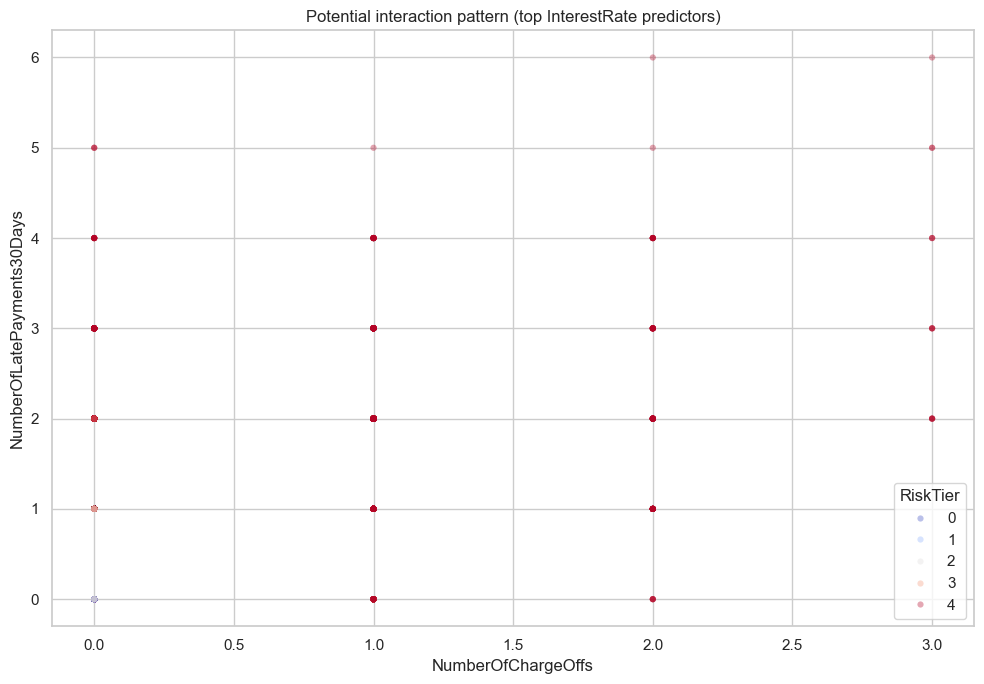

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

eda_df = X_processed.copy()
eda_df['RiskTier'] = y_cls.values
eda_df['InterestRate'] = y_reg.values

corr = eda_df.corr(numeric_only=True)
feature_corr = corr[['RiskTier', 'InterestRate']].drop(
    index=['RiskTier', 'InterestRate'],
    errors='ignore'
)

# 1) Correlation matrix of the most target-relevant features
n_top = min(20, len(feature_corr))
top_features = feature_corr.abs().max(axis=1).sort_values(ascending=False).head(n_top).index.tolist()
heatmap_cols = top_features + ['RiskTier', 'InterestRate']

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr.loc[heatmap_cols, heatmap_cols],
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=False
)
plt.title('Correlation Matrix (Top Features + Targets)')
plt.tight_layout()
plt.show()

# 2) Strongest positive/negative correlations for each target
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, target, color in zip(
    axes,
    ['RiskTier', 'InterestRate'],
    ['#4C72B0', '#DD8452']
):
    target_corr = feature_corr[target].dropna()
    strongest = pd.concat([
        target_corr.nsmallest(8),
        target_corr.nlargest(8)
    ]).drop_duplicates().sort_values()

    sns.barplot(x=strongest.values, y=strongest.index, ax=ax, color=color)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{target}: strongest +/- correlations')
    ax.set_xlabel('Pearson correlation')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

# 3) Missingness impact plots (using new *_is_missing indicators)
indicator_cols = [c for c in X_processed.columns if c.endswith('_is_missing')]
if indicator_cols:
    missing_effects = []
    for c in indicator_cols:
        miss_mask = X_processed[c] == 1
        miss_rate = miss_mask.mean()

        if miss_rate in (0, 1):
            continue

        risk_delta = y_cls.loc[miss_mask].mean() - y_cls.loc[~miss_mask].mean()
        rate_delta = y_reg.loc[miss_mask].mean() - y_reg.loc[~miss_mask].mean()

        missing_effects.append({
            'indicator': c,
            'missing_rate': miss_rate,
            'risk_delta': risk_delta,
            'interest_delta': rate_delta
        })

    missing_effects = pd.DataFrame(missing_effects)

    if not missing_effects.empty:
        top_missing = (
            missing_effects
            .assign(score=lambda d: d['risk_delta'].abs() + d['interest_delta'].abs())
            .nlargest(12, 'score')
        )

        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        sns.barplot(
            data=top_missing.sort_values('risk_delta'),
            x='risk_delta',
            y='indicator',
            ax=axes[0],
            color='#4C72B0'
        )
        axes[0].axvline(0, color='black', linewidth=1)
        axes[0].set_title('RiskTier shift when feature is missing')
        axes[0].set_xlabel('mean(RiskTier | missing) - mean(RiskTier | not missing)')
        axes[0].set_ylabel('')

        sns.barplot(
            data=top_missing.sort_values('interest_delta'),
            x='interest_delta',
            y='indicator',
            ax=axes[1],
            color='#DD8452'
        )
        axes[1].axvline(0, color='black', linewidth=1)
        axes[1].set_title('InterestRate shift when feature is missing')
        axes[1].set_xlabel('mean(InterestRate | missing) - mean(InterestRate | not missing)')
        axes[1].set_ylabel('')

        plt.tight_layout()
        plt.show()
    else:
        print('Missing indicators exist, but no usable split found for target comparison.')
else:
    print('No *_is_missing indicator columns were found.')

# 4) Interaction view: top two InterestRate-correlated features
interest_candidates = feature_corr['InterestRate'].abs().sort_values(ascending=False).index.tolist()
interaction_features = [c for c in interest_candidates if not c.endswith('_is_missing')][:2]

if len(interaction_features) == 2:
    plot_df = eda_df[[interaction_features[0], interaction_features[1], 'RiskTier']].copy()
    plot_df = plot_df.sample(n=min(8000, len(plot_df)), random_state=42)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df,
        x=interaction_features[0],
        y=interaction_features[1],
        hue='RiskTier',
        palette='coolwarm',
        alpha=0.35,
        s=20,
        linewidth=0
    )
    plt.title('Potential interaction pattern (top InterestRate predictors)')
    plt.tight_layout()
    plt.show()


In [7]:
class LinearStackedRiskTier:
    """
    Base learners: RandomForest + XGBoost + LightGBM
    Meta learner: LinearRegression over concatenated class probabilities.
    """
    def __init__(self, base_models, n_splits=5, random_state=42):
        self.base_models = base_models
        self.n_splits = n_splits
        self.random_state = random_state
        self.meta_model = LinearRegression()
        self.fitted_models_ = {}
        self.classes_ = None
        self.oof_pred_ = None

    def _to_class_labels(self, raw_pred):
        return np.clip(np.rint(raw_pred), self.classes_.min(), self.classes_.max()).astype(int)

    def fit(self, X, y):
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)

        self.classes_ = np.sort(y.unique())
        n_classes = len(self.classes_)
        n_models = len(self.base_models)

        oof_meta = np.zeros((len(X), n_models * n_classes), dtype=float)
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for model_idx, (name, model) in enumerate(self.base_models.items()):
            start = model_idx * n_classes
            end = start + n_classes

            for tr_idx, va_idx in skf.split(X, y):
                fold_model = clone(model)
                fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
                oof_meta[va_idx, start:end] = fold_model.predict_proba(X.iloc[va_idx])

            final_model = clone(model)
            final_model.fit(X, y)
            self.fitted_models_[name] = final_model

        self.meta_model.fit(oof_meta, y)
        self.oof_pred_ = self._to_class_labels(self.meta_model.predict(oof_meta))
        return self

    def _meta_features(self, X):
        proba_blocks = [model.predict_proba(X) for model in self.fitted_models_.values()]
        return np.hstack(proba_blocks)

    def predict(self, X):
        raw_pred = self.meta_model.predict(self._meta_features(X))
        return self._to_class_labels(raw_pred)


X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X_processed, y_cls, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")

# Keep scaled data for Task B regression cell.
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_va_sc = scaler.transform(X_val)

base_models = {
    'rf': RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ),
    'xgb': XGBClassifier(
        objective='multi:softprob',
        num_class=5,
        n_estimators=350,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ),
    'lgbm': LGBMClassifier(
        objective='multiclass',
        num_class=5,
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}

clf = LinearStackedRiskTier(base_models=base_models, n_splits=5, random_state=42)
clf.fit(X_train, y_train_cls)


Train: (28000, 71) | Val: (7000, 71)


In [8]:
print("=" * 55)
print("TASK A: RiskTier Classification — Stacked Ensemble")
print("=" * 55)

# OOF train accuracy (less optimistic than in-sample fit)
y_pred_train_cls = clf.oof_pred_
y_pred_cls = clf.predict(X_val)

print(f"Train Accuracy (OOF): {accuracy_score(y_train_cls, y_pred_train_cls)*100:.2f}%")
print(f"Val   Accuracy:       {accuracy_score(y_val_cls, y_pred_cls)*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(
    y_val_cls, y_pred_cls,
    labels=[0, 1, 2, 3, 4],
    target_names=['VeryLow(0)', 'Low(1)', 'Moderate(2)', 'High(3)', 'VeryHigh(4)']
))


TASK A: RiskTier Classification — Stacked Ensemble
Train Accuracy (OOF): 80.83%
Val   Accuracy:       81.23%

Classification Report:
              precision    recall  f1-score   support

  VeryLow(0)       0.87      0.78      0.82      1345
      Low(1)       0.69      0.79      0.73      1456
 Moderate(2)       0.77      0.73      0.75      1400
     High(3)       0.81      0.85      0.83      1362
 VeryHigh(4)       0.96      0.92      0.94      1437

    accuracy                           0.81      7000
   macro avg       0.82      0.81      0.81      7000
weighted avg       0.82      0.81      0.81      7000



In [9]:
print("=" * 55)
print("TASK B: InterestRate Regression — Linear Regression")
print("=" * 55)

reg = LinearRegression()
reg.fit(X_tr_sc, y_train_reg)

y_pred_reg = reg.predict(X_va_sc)
val_r2     = r2_score(y_val_reg, y_pred_reg)
val_rmse   = mean_squared_error(y_val_reg, y_pred_reg) ** 0.5

print(f"Train R²:  {r2_score(y_train_reg, reg.predict(X_tr_sc)):.4f}")
print(f"Val   R²:  {val_r2:.4f}")
print(f"Val RMSE:  {val_rmse:.4f}%")
print(f"Val MAE:   {np.mean(np.abs(y_val_reg - y_pred_reg)):.4f}%")

# TODO: Try RandomForestRegressor, XGBRegressor

TASK B: InterestRate Regression — Linear Regression
Train R²:  0.6217
Val   R²:  0.6264
Val RMSE:  2.6360%
Val MAE:   1.7207%


In [ ]:
test = pd.read_csv('credit_test.csv')

_, X_test_proc = simple_preprocess(X, test)
X_test_scaled  = scaler.transform(X_test_proc)

pred_cls = clf.predict(X_test_scaled)
pred_reg = np.clip(reg.predict(X_test_scaled), 4.99, 35.99).round(2)

submission = pd.DataFrame({
    'Id':           range(len(pred_cls)),
    'RiskTier':     pred_cls,
    'InterestRate': pred_reg,
})
submission.to_csv('submission.csv', index=False)

print("Saved submission.csv")
print(f"\nPreview:\n{submission.head(10).to_string(index=False)}")
print(f"\nRiskTier counts:\n{pd.Series(pred_cls).value_counts().sort_index()}")
print(f"\nInterestRate summary:\n{pd.Series(pred_reg).describe().round(2)}")

Numeric: 46 | Categorical: 9 | Missing indicators: 16
Saved submission.csv

Preview:
 Id  RiskTier  InterestRate
  0         2          5.68
  1         0          6.30
  2         3          6.68
  3         3          7.48
  4         4         17.73
  5         3          6.46
  6         2          6.33
  7         2          5.62
  8         3          6.35
  9         2          5.62

RiskTier counts:
0    2620
1    3571
2    2766
3    3148
4    2895
Name: count, dtype: int64

InterestRate summary:
count    15000.00
mean         7.36
std          3.38
min          4.99
25%          5.54
50%          6.09
75%          7.37
max         35.99
dtype: float64
